# IID Data

In [1]:
# IID 데이터 생성 함수
def client_data_iid(dataset, num_clients):
    num_items = int(len(dataset) / num_clients)  # 각 클라이언트가 가져갈 데이터의 수
    dataset_index = list(range(len(dataset)))  # 전체 데이터셋의 인덱스
    random.shuffle(dataset_index)  # 인덱스 섞기
    client_datasets = []
    for i in range(num_clients):
        # 각 클라이언트에 대한 인덱스 하위 리스트 생성
        client_datasets.append(dataset_index[i * num_items:(i + 1) * num_items])  #슬라이싱으로 나누기 dataset_index를
    return client_datasets
num_clients=30
client_data_indices=client_data_iid(mnist_train,num_clients)
print(client_data_indices[0])
print(len(client_data_indices[0]))

from collections import Counter

list_of_samples=[]
def print_label_distribution(client_datasets, dataset):
    """ 각 클라이언트의 라벨 분포와 데이터의 총 개수를 출력 """
    num_clients = len(client_datasets)

    for client_id, indices in enumerate(client_datasets):
        labels = [dataset[i][1] for i in indices]  # 각 클라이언트의 인덱스를 사용하여 라벨 추출
        label_counts = Counter(labels)  # 라벨 카운트
        total_data = len(labels)  # 클라이언트가 가진 데이터의 총 개수
        list_of_samples.append(total_data)
        print(f"Client {client_id + 1} has {total_data} data points.")
        print(f"Label distribution: {dict(label_counts)}")
        print()  # 각 클라이언트 정보 간의 간격을 주기 위해 빈 줄 추가

# 클라이언트별 라벨 분포와 데이터 개수 출력
print_label_distribution(client_data_indices, mnist_train)
print(list_of_samples)
print(len(list_of_samples))


NameError: name 'mnist_train' is not defined

In [ ]:
#IID
def get_client_dataloader(mnist_dataset, client_data_indices, shuffle=True):
    """
    클라이언트별 DataLoader를 생성하는 함수

    - mnist_dataset: 전체 MNIST 데이터셋 (torchvision.datasets.MNIST)
    - client_data_indices: 각 클라이언트별 데이터 인덱스 (dict)
    - batch_size: DataLoader의 배치 크기
    - shuffle: 데이터 섞을지 여부

    반환값:
    - client_dataloaders: 클라이언트별 DataLoader 딕셔너리
    """
    client_dataloaders = {}
    client_data_indices = {i: indices for i, indices in enumerate(client_data_indices)}
    for client_id, indices in client_data_indices.items():
        batch_size=len(client_data_indices[client_id])
        client_subset = Subset(mnist_dataset, indices)  # 클라이언트별 데이터 서브셋 생성
        dataloader = DataLoader(client_subset, batch_size=batch_size, shuffle=shuffle)
        client_dataloaders[client_id] = dataloader

    return client_dataloaders
batch_size=len(client_data_indices[client_id])
client_dataloaders = get_client_dataloader(mnist_train, client_data_indices, shuffle=True)

TypeError: object of type 'int' has no len()

In [ ]:
def split_mnist_noniid_fixed(mnist_dataset, num_clients, seed):
    """
    MNIST 데이터를 Non-IID로 클라이언트에 분배하는 함수 (각 클라이언트가 정확히 2개 클래스만 가지도록 보장)
    - num_clients: 클라이언트 개수
    - seed: 랜덤 시드 고정 (재현 가능성)

    반환값:
    - client_data: 클라이언트별 데이터 인덱스 리스트 (딕셔너리 형태)
    """
    np.random.seed(seed)

    num_samples = len(mnist_dataset)
    indices = np.arange(num_samples)
    labels = np.array(mnist_dataset.targets)

    # 각 숫자(0~9)별로 데이터를 분리
    label_dict = {i: indices[labels == i] for i in range(10)}

    # 각 숫자를 2개의 샤드로 분할
    num_shards = max(num_clients * 2, 20)
    shards_per_label = num_shards // 10  # 숫자당 샤드 개수
    shards = []

    for label, idx in label_dict.items():
        np.random.shuffle(idx)  # 섞기
        shard_size = len(idx) // shards_per_label  # 각 샤드 크기
        label_shards = [idx[i * shard_size: (i + 1) * shard_size] for i in range(shards_per_label)]
        shards.extend([(shard, label) for shard in label_shards])  # 라벨 정보 추가

    np.random.shuffle(shards)  # 샤드를 섞음
    client_data = {i: [] for i in range(num_clients)}

    # 클라이언트에 정확히 2개 샤드 할당 (2개 숫자 보장)
    used_labels = set()
    for i in range(num_clients):
        while True:
            selected_shards = np.random.choice(len(shards), 2, replace=False)
            shard_labels = {shards[idx][1] for idx in selected_shards}  # 선택한 샤드의 라벨 집합
            if len(shard_labels) == 2:  # 두 개의 다른 클래스를 가져야 함
                break

        for shard_idx in selected_shards:
            client_data[i].extend(shards[shard_idx][0])  # 데이터 인덱스 저장
        used_labels.update(shard_labels)  # 사용된 라벨 업데이트

        # 선택된 샤드 제거 (중복 방지)
        for shard_idx in sorted(selected_shards, reverse=True):
            del shards[shard_idx]

    return client_data

# Non-IID 데이터 생성 (각 클라이언트가 2개 숫자만 가지도록 보장)
num_clients = 30
client_data_indices = split_mnist_noniid_fixed(mnist_train, num_clients=num_clients, seed=0)
print(client_data_indices[0])
print(len(client_data_indices[0]))

# 클라이언트별 데이터 라벨 분포 확인
total_samples_per_client = {}
for client_id, indices in client_data_indices.items():
    labels = mnist_train.targets[indices]  # 해당 클라이언트의 데이터 라벨 가져오기
    label_counts = collections.Counter(labels.numpy())  # 라벨별 개수 세기
    total_samples = sum(label_counts.values())  # 총 데이터 개수 계산
    total_samples_per_client[client_id] = total_samples  # 딕셔너리에 저장
    print(f"Client {client_id}: {dict(label_counts)}, Total Samples: {total_samples}")

# 전체 클라이언트 데이터 개수 확인
print("Total samples per client:", total_samples_per_client)

# 딕셔너리 값들을 리스트로 추출하여 새로운 리스트 생성
list_of_samples = list(total_samples_per_client.values())
print("Total samples per client (list):", list_of_samples)



[47800, 30912, 38728, 31156, 56837, 35845, 21894, 10533, 44409, 17388, 51634, 27219, 46426, 6707, 42959, 57702, 21240, 47439, 35102, 446, 33796, 3442, 25792, 52752, 5473, 43337, 59703, 46084, 34981, 10735, 40465, 56064, 51344, 29508, 24415, 50370, 918, 53702, 15895, 2161, 20980, 55384, 48712, 34914, 27554, 23068, 4991, 48648, 9787, 15740, 19344, 42281, 1191, 3728, 30532, 24788, 30380, 30502, 31477, 59937, 56209, 32681, 8396, 51193, 41472, 50920, 4372, 4499, 42695, 18910, 48988, 55885, 16015, 51000, 29796, 26026, 15425, 25350, 31571, 39687, 58349, 36465, 39868, 3942, 30558, 34690, 37215, 25160, 13053, 53886, 29296, 17525, 34676, 56432, 30462, 55802, 33995, 18265, 43470, 911, 58941, 10946, 17109, 193, 54378, 48452, 1656, 31698, 57556, 25522, 24041, 4726, 32428, 1833, 27717, 39729, 50224, 54115, 55709, 34861, 23070, 11877, 35957, 18006, 1412, 52436, 44252, 301, 43187, 55915, 43919, 41224, 53183, 32613, 17069, 30982, 11640, 16842, 44949, 10788, 54731, 44663, 10573, 11049, 54478, 52937, 513

In [ ]:
def get_single_dataloader(mnist_dataset, client_data_indices, shuffle=True):
    """
    하나의 DataLoader만 생성하고, 클라이언트별 데이터를 인덱싱하여 사용.

    - mnist_dataset: 전체 MNIST 데이터셋
    - client_data_indices: 클라이언트별 데이터 인덱스 (dict)
    - shuffle: 데이터 섞을지 여부

    반환값:
    - 전체 데이터에 대한 단일 DataLoader
    - 클라이언트별 인덱스 리스트
    """
    all_indices = sum(client_data_indices.values(), [])  # 모든 클라이언트의 인덱스를 하나로 합침
    batch_size = len(all_indices)  # 한 번에 전체 데이터를 로드
    full_dataloader = DataLoader(Subset(mnist_dataset, all_indices), batch_size=batch_size, shuffle=shuffle)

    return full_dataloader, client_data_indices


full_dataloader, client_indices = get_single_dataloader(mnist_train, client_data_indices, shuffle=True)

# Scheduling(Importance & Channel Awareness)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import random
import time
import math
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
import collections
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import multiprocessing

random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
# 데이터 전처리
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.RandomRotation(10),  # Add random rotation
    transforms.RandomHorizontalFlip(),  # Add random horizontal flip
])

# MNIST 데이터셋 다운로드
mnist_train = dsets.MNIST(root='MNIST_data/', train=True, transform=transform, download=True)
mnist_test = dsets.MNIST(root='MNIST_data/', train=False, transform=transform, download=True)
print(len(mnist_train))
print(len(mnist_test))

cuda:0
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.56MB/s]


Extracting MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]


Extracting MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]


Extracting MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.85MB/s]

Extracting MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw

60000
10000


In [2]:
#non-iid
#samples_local_non_iid = np.full(K, len(x) // K)

K=30
num_classes=2
samples_avg_local=2000

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.MNIST(root='./MNIST_dataset/', train=True, download=True, transform=transform)

x, y = zip(*trainset)
x = torch.stack(list(x), dim = 0)
list_of_samples = np.full(K, len(x) // K)
y = np.array(y)

idx = [list((y==i).nonzero()[0]) for i in range(10)]   # Indices for each of ten classies

idx_localDB_non_iid = []
for i in range(K):
    types = np.random.choice(10, num_classes, replace=False)

    tmp = []
    for j in range(num_classes):
        tmp += idx[types[j]]

    idx_localDB_non_iid.append(list(np.random.choice(tmp, list_of_samples[i], replace=False)))

testset = torchvision.datasets.MNIST(root='./MNIST_dataset/', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=samples_avg_local, shuffle=False, num_workers=2)

classes = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:10<00:00, 912kB/s] 


Extracting ./MNIST_dataset/MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST_dataset/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]


Extracting ./MNIST_dataset/MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST_dataset/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]


Extracting ./MNIST_dataset/MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST_dataset/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.02MB/s]


Extracting ./MNIST_dataset/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST_dataset/MNIST/raw



In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 5)
        self.fc1 = nn.Linear(64 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        #x = self.pool(torch.tanh(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        #x = self.pool(torch.tanh(self.conv2(x)))
        x = x.view(-1, 64 * 4 * 4)
        x = torch.relu(self.fc1(x))
        #x = torch.tanh(self.fc1(x))
        x = self.fc2(x)
        return x

global_model = SimpleCNN()
global_model=global_model.to(device)

In [4]:
#Experiment Settings
num_clients=30
num_rounds=300
K=30
M=28
lr=0.01

S=sum( p.numel() for p in global_model.parameters() if p.requires_grad)
print('S:',S)
q=16
C=11094336


B=10**6
rho=1e-3

S: 582026


In [5]:
#클라이언트 분포 거리, d
#면적에 따라 확률분포하는 방식으로 수정
def generate_client_distances(num_clients, radius):

    angles = np.random.uniform(0, 2 * np.pi, num_clients)  # 0~2π 사이 균등 분포 (각도)
    distances = radius * np.sqrt(np.random.uniform(0, 1, num_clients))  # 넓이 기반 샘플링

    # x, y 좌표 변환
    x_coords = distances * np.cos(angles)
    y_coords = distances * np.sin(angles)

    return distances

In [6]:
#Client 학습
#local_epoch=1, 모든데이터를 한번씩 다 훈련 --> gradient만 출력 받을 꺼야

def local_train(k):
    local_model=deepcopy(global_model)
    local_model.to(device)
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.SGD(local_model.parameters(),lr=lr)
    accumulated_grads = [torch.zeros_like(param) for param in local_model.parameters()]


    inputs = x[idx_localDB_non_iid[k]].to(device)
    labels = torch.tensor(y[idx_localDB_non_iid[k]], dtype=torch.long).to(device)
    permut_idx = np.random.permutation(len(inputs))
    inputs = inputs[permut_idx]
    labels = labels[permut_idx]
    outputs = local_model(inputs)
    loss = criterion(outputs, labels)
    local_model.zero_grad()
    loss.backward()


    for idx, param in enumerate(local_model.parameters()):
        if param.grad is not None:
            accumulated_grads[idx] += param.grad.clone()

    return accumulated_grads

In [7]:
#Importance, Gradient norm, Latency, p_t_k 계산 함수

#Gradient norm
def gradient_norm(client_gradients):
    grad_norms=[]
    for client_gradient in client_gradients:
        client_norm=0.0
        for grad in client_gradient:
            if grad is not None:
               client_norm +=torch.norm(grad.double()).item()**2
        client_norm = torch.sqrt(torch.tensor(client_norm)) # norm 계산
        grad_norms.append(client_norm.type(torch.float64)) # double형 tensor로 저장
    return grad_norms
#SNR
device_power = 24 # dBm
device_power_db = -6 #dB
device_power_linear = 10 ** (device_power_db  /10 )

#path_loss_db = 128.1 + 37.6 * np.log10(distances)
#path_loss_linear = 10 ** (path_loss_db / 10)

noise_density = -174 # dBm/Hz
N_db = noise_density + 10 * np.log10(B) # -114dBm
N_db -= 30 # db scale -144dB
N_linear = 10 ** (N_db/ 10)

fading_squared = np.random.exponential(scale=1.0, size=K)

#SNR_up_numerator = (device_power_linear * fading_squared) / path_loss_linear
#SNR_up_denominator = N_linear
#SNR_up = SNR_up_numerator / SNR_up_denominator

#Latency
def Latency():
    channel=B*np.log2(1+SNR_up)
    return S*q/channel

#p_t_k
def compute_p_t_k(n_k, n, grad_norm, rho, latency, lambda_t_star):
    """
    클라이언트 선택 확률 p_t^k 를 계산합니다.

    Args:
        n_k: 클라이언트 k의 로컬 데이터 샘플 수 (int)
        n: 전체 클라이언트의 총 로컬 데이터 샘플 수 (int)
        grad_norm: 클라이언트 k의 gradient norm (torch.Tensor)  <- 변경됨
        rho: 하이퍼파라미터 (float 또는 torch.Tensor)
        latency: 각 클라이언트의 지연 시간 (numpy.ndarray)
        lambda_t_star: Lagrangian multiplier (float 또는 torch.Tensor)
        client_id: 클라이언트 ID (int)

    Returns:
        클라이언트 k의 선택 확률 p_t^k (torch.Tensor)
    """
    latency_value = torch.tensor(latency[client_id]).double()  # numpy.ndarray -> torch.Tensor, double형으로 변환
    numerator = torch.tensor(n_k / n).double() * grad_norm.double()  # n_k / n * ||g_k^t||
    denominator = torch.sqrt(torch.tensor(rho).double() / ((1 - torch.tensor(rho).double()) * latency_value + torch.tensor(lambda_t_star).double()))
    pk=numerator * denominator
    return pk


In [8]:
def find_lambda_brute_force(len_all, grad_norm, T_up, rho=1e-3, max_iter=10000, tol=1e-7, initial_step=10.0):
    total_n = np.sum(len_all)

    # λ의 초기 탐색 범위 설정
    T_up_array = np.array(T_up)
    lam_min = -np.min((1 - rho) * T_up_array) + 1e-6  # 안전 마진 추가
    lam = lam_min  # 초기값
    step = initial_step  # 초기 이동 간격

    def compute_p_sum(lam):
        """주어진 λ에 대해 p_k 값의 합을 계산"""
        sum_p = 0.0
        for i in range(len(len_all)):
            denominator = (1 - rho) * T_up[i] + lam
            if denominator <= 0:
                return np.inf  # 불가능한 값이 나오면 큰 값 반환
            sum_p += (len_all[i] / total_n) * float(grad_norm[i]) * np.sqrt(rho / denominator)
        return sum_p

    # 탐색 수행
    for _ in range(max_iter):
        p_sum = compute_p_sum(lam)

        if abs(p_sum - 1.0) < tol:  # 충분히 정확하면 종료
            return lam

        if p_sum > 1.0:
            lam += step  # λ 증가
        else:
            lam -= step  # λ 감소

        step *= 0.9  # 점진적으로 step 크기를 줄여 정밀하게 조정

        if step < tol:  # 더 이상 좁힐 수 없는 경우 종료
            break

    return lam

In [9]:
#전체 학습 과정

total_time=0
train_acc_history=[]
time_history = []
for round in range(num_rounds):

#distance & SNR
    distances=generate_client_distances(num_clients, radius=0.5) #[km]
    print('distances:',distances)
    path_loss_db = 128.1 + 37.6 * np.log10(distances)
    path_loss_linear = 10 ** (path_loss_db / 10)
    SNR_up_numerator = (device_power_linear * fading_squared) / path_loss_linear
    SNR_up_denominator = N_linear
    SNR_up = SNR_up_numerator / SNR_up_denominator
    print('SNR:',SNR_up)
#Global Model Broadcast Latency
    global_latency=S*q/B*np.log2(1+min(SNR_up))
    print('global_latency:',global_latency)
#Local Gradient Calculation Latency
#   n_k*C/f_k
#Step1 Global Model Broadcast
#local_train 함수 내부에서 deepcopy를 통해 실행
#Step2 Local Gradient Calculation
    client_gradients=[]
    for k in range(K):
      client_gradient=local_train(k)
      client_gradients.append(client_gradient)

#Step3 Importance Indicaor Report

    #norm 계산
    grad_norms=gradient_norm(client_gradients) #리스트

    #Latency 계산
    latency_values=Latency() #numpy.ndarray
    print('Latency:',latency_values)
    #p_t_k
    lambda_t_star=find_lambda_brute_force(list_of_samples, grad_norms, latency_values, rho=rho)
    print('lambda_t_star:',lambda_t_star)
    p_t_k = []
    for client_id in range(K):
      p_t_k_value = compute_p_t_k(list_of_samples[client_id], sum(list_of_samples), grad_norms[client_id], rho, latency_values, lambda_t_star)
      p_t_k.append(p_t_k_value)
    p_t_k_tensor = torch.stack(p_t_k)
    p_t_k_normalized = p_t_k_tensor / torch.sum(p_t_k_tensor)
    p_sum = torch.sum(p_t_k_normalized) #
    print('p_t_k:', p_t_k_normalized)
    print('p_sum:', p_sum)

#Step4 Device Selection and Resource Allocation
    p_t_k_values = p_t_k_normalized.tolist()
    clients=np.arange(K)
    selected_clients = np.random.choice(clients, size=M, p=p_t_k_values,replace=False)
    print("Selected Clients:", selected_clients)
#Selected Client Bandwidth allocation & Latency 통일
    Upload_Latencies=[]
    for client_id in selected_clients:
        R_k_t=1/np.log2(1+SNR_up[client_id])
    inverse_R_k_t_sum=1/np.sum(1/np.log2(1+SNR_up[selected_clients]))
    B_k_t= (B/R_k_t)*inverse_R_k_t_sum
    for client_id in selected_clients:
        Upload_Latency=q*S/(B_k_t*np.log2(1+SNR_up[client_id]))
        Upload_Latencies.append(Upload_Latency)
        print(f"Upload_Latency({client_id}):",Upload_Latency)
    client_upload_Latency=max(Upload_Latencies)
#Whole Latency
    whole_latency=global_latency+client_upload_Latency
    print('whole_latency:',whole_latency)
#Step5 Local Gradient Upload
    n_sum=[]
    for index in selected_clients:
        n=list_of_samples[index]
        n_sum.append(n)
    global_gradients = []
    for index in selected_clients:
        global_gradient = [torch.mul(grad, list_of_samples[index] / sum(n_sum)) for grad in client_gradients[index]]
        global_gradients.append(global_gradient)
    new_global_gradient = [torch.stack(grads).sum(dim=0) for grads in zip(*global_gradients)]
#Step6 Global Gradient Update
    for param, grad in zip(global_model.parameters(), new_global_gradient):
        param.data -= lr * grad

#Time
    total_time += whole_latency
    time_history.append(total_time)
    print(f"Time({round}/{num_rounds}): {whole_latency:.2f} seconds | Total Time: {total_time:.2f} seconds")
#Accuracy
    correct = 0
    total_samples = 0
    with torch.no_grad():
        for data in testloader:
            images_tmp, labels = data
            images = images_tmp.to(device)
            outputs = global_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct += (predicted.cpu() == labels).sum().item()

    train_acc_history.append( correct / total_samples)
    print('Accuracy for 10,000 test images: %.2f %%' % (100.0 * train_acc_history[round]))





스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Upload_Latency(11): 0.793049907511568
Upload_Latency(24): 0.4453413043790154
Upload_Latency(10): 0.5901172460102665
Upload_Latency(26): 0.5288034215340917
Upload_Latency(23): 0.6555619274747836
Upload_Latency(14): 0.5301968401252563
Upload_Latency(9): 0.6374907374303107
Upload_Latency(29): 0.7823122300846409
Upload_Latency(2): 0.6084020432548093
Upload_Latency(16): 1.1572042765942119
Upload_Latency(15): 0.5821644459258433
Upload_Latency(13): 0.7903777447767618
Upload_Latency(8): 0.8601508303072231
Upload_Latency(27): 0.8265152745474912
Upload_Latency(19): 0.5150559012486235
Upload_Latency(0): 0.8592460253956652
Upload_Latency(18): 0.5153102342462944
Upload_Latency(28): 0.5022147755857002
Upload_Latency(21): 1.1382235572491999
Upload_Latency(6): 0.8089194876158378
Upload_Latency(3): 0.8157179863319883
whole_latency: 36.01422763075275
Time(213/300): 36.01 seconds | Total Time: 7194.55 seconds
Accuracy for 10,000 test images: 62.03 %
distances: [0.14564

#Result Time=Latency, Round=300

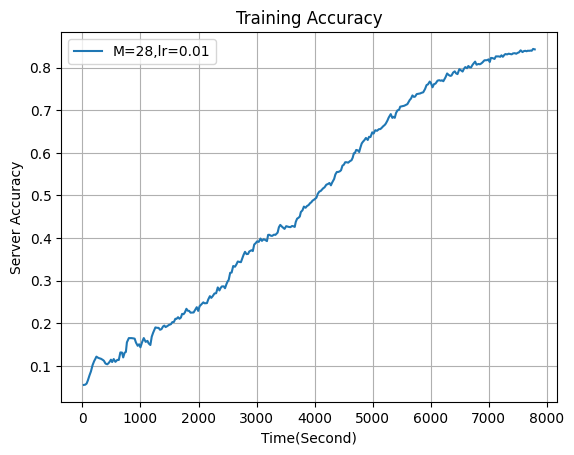

In [10]:
plt.plot(time_history,train_acc_history, label = "M=28,lr=0.01")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()

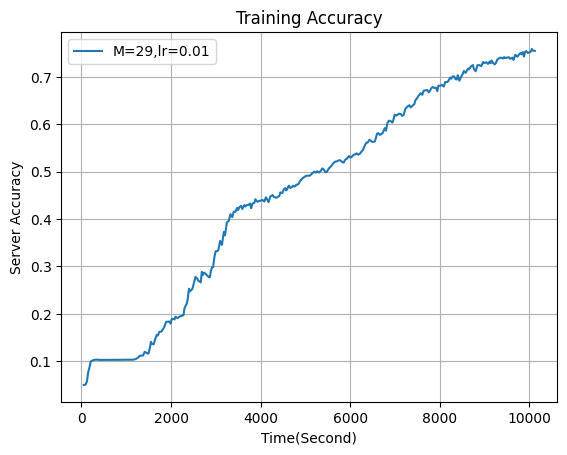

In [10]:

plt.plot(time_history,train_acc_history, label = "M=29,lr=0.01")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()

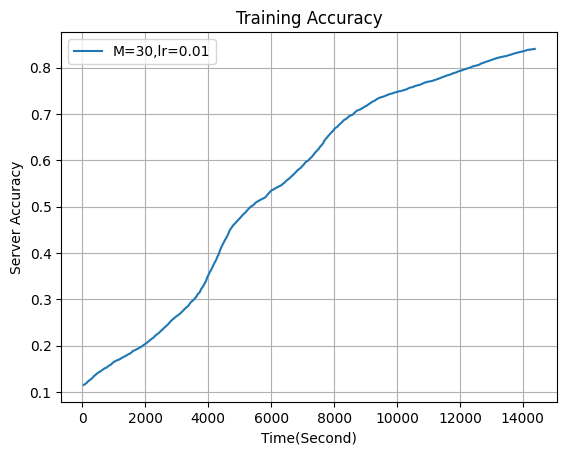

In [ ]:
del time_history[-1]
plt.plot(time_history,train_acc_history, label = "M=30,lr=0.01")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()

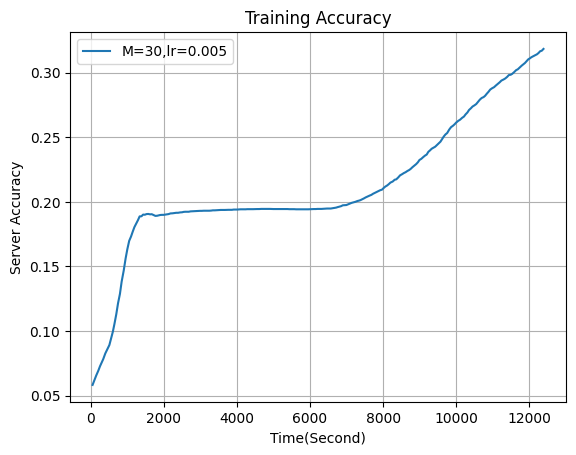

In [ ]:
del time_history[-1]
plt.plot(time_history,train_acc_history, label = "M=30,lr=0.005")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()

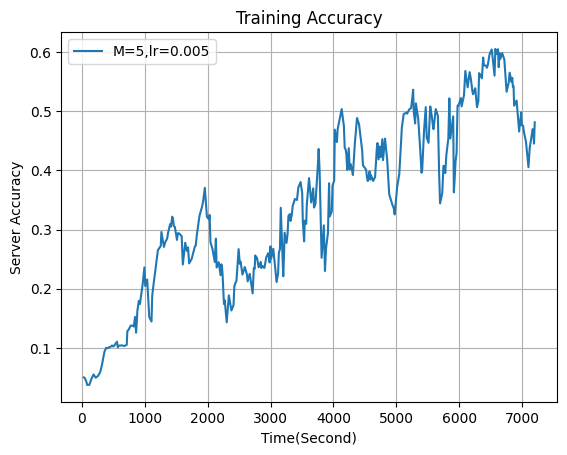

In [ ]:
del time_history[-1]
plt.plot(time_history,train_acc_history, label = "M=5,lr=0.005")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()

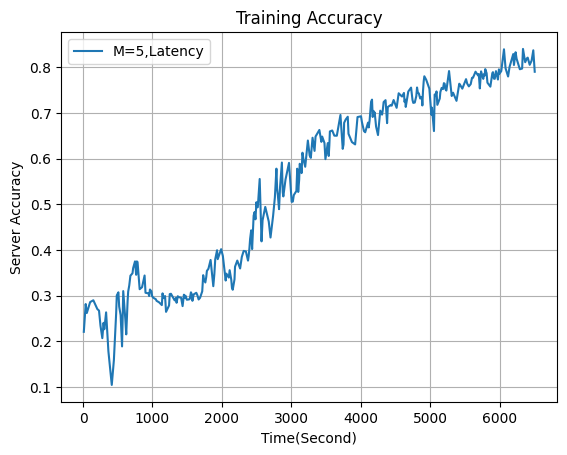

In [ ]:
plt.plot(time_history,train_acc_history, label = "M=5,Latency")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()

# Result/ x축 에포크 당 latency 고려/ M=30 해보기

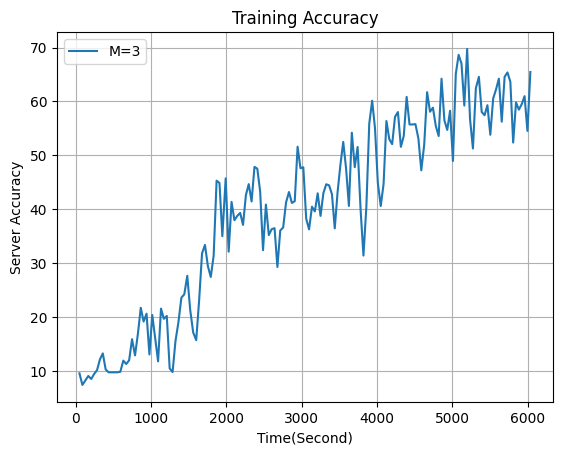

In [ ]:
plt.plot(time_history,accuracy_history, label = "M=3")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()

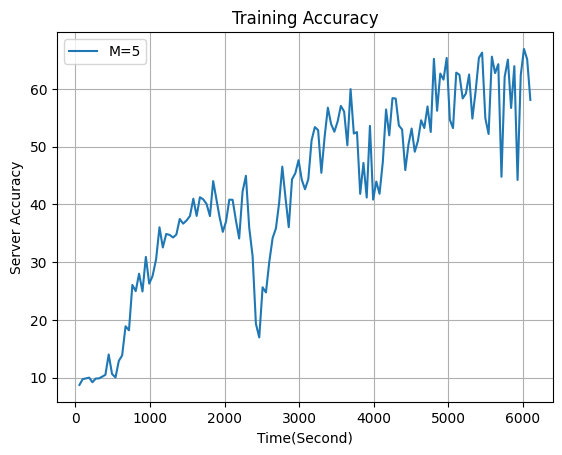

In [ ]:
plt.plot(time_history,accuracy_history, label = "M=5")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()

In [ ]:
plt.plot(time_history,accuracy_history, label = "M=10")
plt.xlabel("Time(Second)")
plt.ylabel("Server Accuracy")
plt.title("Training Accuracy")
plt.grid()
plt.legend()


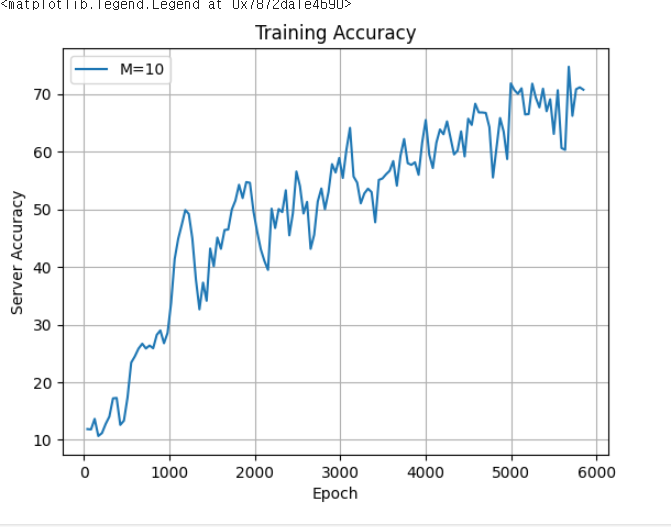
```

